# 💾 Bloque 2 — Principales sistemas de almacenamiento y formatos

**Módulo:** Extracción, Transformación y Carga de Datos desde Fuentes Múltiples (5104)
**Unidad Didáctica:** UD1 — Tipología y características de las fuentes de datos
**Duración estimada:** ~6 horas
**Curso académico:** 2026-2027

---

### Contenidos de este bloque

| Epígrafe | Contenido |
|----------|-----------|
| **2.1** | Bases de datos relacionales (SQL): modelo relacional y uso en ML |
| **2.2** | Bases de datos NoSQL: documentos, clave-valor, columnar y grafos |
| **2.3** | Formatos de intercambio: CSV, JSON y XML |
| **2.4** | Formatos orientados a ML: Parquet, Apache Arrow y HDF5 |
| **2.5** | Sistemas IoT y SCADA: series temporales y ML industrial |

### Criterios de evaluación asociados
> **(CE d)** Se han descrito los sistemas gestores de datos SQL y no SQL, diferenciando sus estructuras, modelos y aplicaciones actuales.
> **(CE e)** Se han analizado los formatos de texto estructurados para el intercambio de datos, tales como ficheros planos, XML y JSON.
> **(CE f)** Se han determinado el formato y la utilidad de los datos procedentes de sistemas SCADA aplicados en IoT.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import json
import sqlite3
import time
import os
import io
import xml.etree.ElementTree as ET
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Librerias cargadas correctamente.")


Librerias cargadas correctamente.


---
## 2.1 Bases de datos relacionales (SQL)

El **modelo relacional** organiza los datos en **tablas** (relaciones) formadas por filas (tuplas) y columnas (atributos). Su fortaleza es la **integridad referencial**: las claves foráneas garantizan que los datos son consistentes entre tablas.

En proyectos de ML, las BD relacionales son la fuente más común de datos tabulares estructurados listos para entrenar. El flujo habitual es:

```
BD relacional  -->  pd.read_sql_query(sql, conn)  -->  DataFrame  -->  sklearn / XGBoost / ...
```

### Principales sistemas y cuándo usarlos en ML

| SGBD | Tipo de despliegue | Caso de uso en ML | Característica clave |
|------|--------------------|-------------------|----------------------|
| [**SQLite**](https://www.sqlite.org) | Fichero local, sin servidor | Prototipado, tests, cuadernos | Cero configuración |
| [**PostgreSQL**](https://www.postgresql.org) | Servidor gestionado o nube | Producción corporativa, feature stores | Extensiones (pgvector, PostGIS) |
| [**MySQL**](https://www.mysql.com) / [**MariaDB**](https://mariadb.org) | Servidor web | Datos de aplicaciones web y e-commerce | Ecosistema muy amplio |
| [**DuckDB**](https://duckdb.org) | Embebido (como SQLite) | SQL analítico sobre Parquet/CSV, ETL | Velocidad OLAP en local |

> 💡 **DuckDB** es el gran protagonista emergente: permite hacer SQL analítico directamente sobre ficheros Parquet o CSV sin cargar todo en memoria. Ideal para exploración inicial de datasets grandes en un cuaderno.


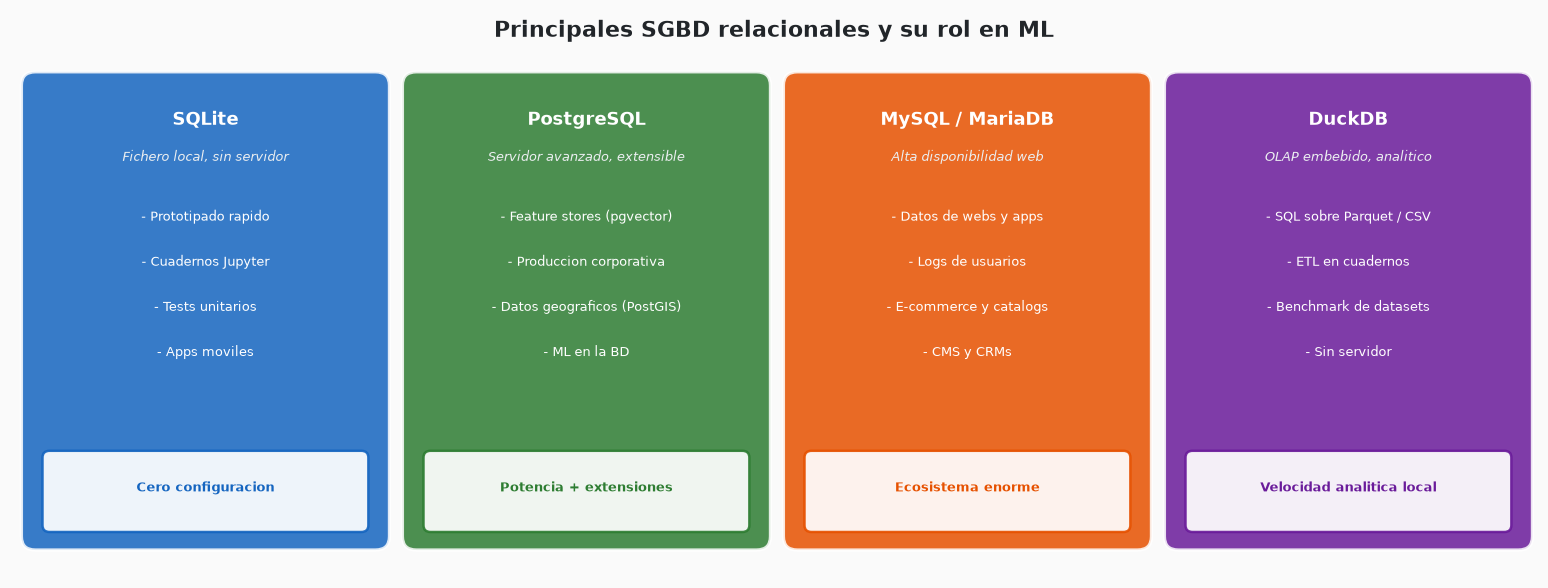

In [2]:
# ── Diagrama 1: SGBD relacionales y su rol en ML ─────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

ax.text(6.5, 4.78, 'Principales SGBD relacionales y su rol en ML',
        ha='center', fontsize=15, fontweight='bold', color='#212529')

sgbd_data = [
    (0.2,  '#1565C0', 'SQLite',
     'Fichero local, sin servidor',
     ['Prototipado rapido', 'Cuadernos Jupyter', 'Tests unitarios', 'Apps moviles'],
     'Cero configuracion'),

    (3.45, '#2E7D32', 'PostgreSQL',
     'Servidor avanzado, extensible',
     ['Feature stores (pgvector)', 'Produccion corporativa', 'Datos geograficos (PostGIS)', 'ML en la BD'],
     'Potencia + extensiones'),

    (6.7,  '#E65100', 'MySQL / MariaDB',
     'Alta disponibilidad web',
     ['Datos de webs y apps', 'Logs de usuarios', 'E-commerce y catalogs', 'CMS y CRMs'],
     'Ecosistema enorme'),

    (9.95, '#6A1B9A', 'DuckDB',
     'OLAP embebido, analitico',
     ['SQL sobre Parquet / CSV', 'ETL en cuadernos', 'Benchmark de datasets', 'Sin servidor'],
     'Velocidad analitica local'),
]

for x0, color, nombre, desc, usos, ventaja in sgbd_data:
    box = FancyBboxPatch((x0, 0.35), 2.9, 4.0,
                         boxstyle='round,pad=0.12',
                         facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    ax.add_patch(box)
    ax.text(x0 + 1.45, 4.0, nombre,
            ha='center', fontsize=13, fontweight='bold', color='white')
    ax.text(x0 + 1.45, 3.68, desc,
            ha='center', fontsize=9.5, color='#ECEFF1', style='italic')
    for j, uso in enumerate(usos):
        ax.text(x0 + 1.45, 3.15 - j * 0.4, '- ' + uso,
                ha='center', fontsize=9.8, color='white')
    # Caja de ventaja clave
    vbox = FancyBboxPatch((x0 + 0.12, 0.45), 2.66, 0.6,
                           boxstyle='round,pad=0.06',
                           facecolor='white', edgecolor=color, linewidth=1.5, alpha=0.92)
    ax.add_patch(vbox)
    ax.text(x0 + 1.45, 0.75, ventaja,
            ha='center', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()


### Escenario: predicción de abandono (churn) en un e-commerce

**Problema que se quiere resolver:**
Una empresa de venta online quiere predecir qué clientes tienen mayor probabilidad
de **abandonar la plataforma** (churn) en los próximos 30 días. Identificar estos
clientes con antelación permite lanzar campañas de retención personalizadas.

**Fuentes de datos disponibles** (tres tablas relacionales):

- **`clientes`** — datos estáticos: identificador, país y fecha de alta.
  Permite calcular la antigüedad del cliente.
- **`pedidos`** — historial de compras: importe, fecha y si el pedido fue
  completado o cancelado. Aporta señales de frecuencia y satisfacción.
- **`incidencias`** — reclamaciones de soporte: tipo y si fueron resueltas.
  Un alto número de incidencias sin resolver correlaciona con el churn.

**Cómo se construye la tabla de features:**
Con un JOIN y agregaciones SQL (`COUNT`, `SUM`, `AVG`) combinamos las tres tablas
en una fila por cliente: número de pedidos, gasto total, ticket medio,
pedidos cancelados, incidencias e incidencias sin resolver.
El resultado se carga con `pd.read_sql_query()` directamente en pandas.

El diagrama siguiente muestra el esquema E-R de la base de datos:


In [ ]:
# -- Diagrama E-R: base de datos de churn en e-commerce
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5.5)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

ax.text(6.5, 5.25, 'Diagrama E-R: prediccion de churn en e-commerce',
        ha='center', fontsize=17, fontweight='bold', color='#212529')

C_ENT  = '#1565C0'
C_HEAD = '#0D47A1'
C_ATR  = '#E3F2FD'
C_PK   = '#FFF9C4'
C_FK   = '#F3E5F5'
C_REL  = '#EF6C00'

def tabla_er(ax, x, y, nombre, campos, w=3.0, row_h=0.36):
    n = len(campos)
    cab = FancyBboxPatch((x, y + row_h * n), w, row_h,
                          boxstyle='round,pad=0.04',
                          facecolor=C_HEAD, edgecolor=C_ENT, linewidth=2)
    ax.add_patch(cab)
    ax.text(x + w/2, y + row_h * n + row_h/2, nombre,
            ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    for i, (campo, tipo, flag) in enumerate(campos):
        fc = C_PK if flag == 'PK' else (C_FK if flag == 'FK' else C_ATR)
        fila = FancyBboxPatch((x, y + row_h * i), w, row_h,
                               boxstyle='round,pad=0.02',
                               facecolor=fc, edgecolor='#90CAF9', linewidth=1)
        ax.add_patch(fila)
        prefix = 'PK  ' if flag == 'PK' else ('FK  ' if flag == 'FK' else '    ')
        ax.text(x + 0.14, y + row_h * i + row_h/2, prefix + campo,
                ha='left', va='center', fontsize=11,
                fontweight='bold' if flag == 'PK' else 'normal', color='#1A237E')
        ax.text(x + w - 0.1, y + row_h * i + row_h/2, tipo,
                ha='right', va='center', fontsize=10, color='#546E7A', style='italic')

def rombo(ax, cx, cy, texto, color=C_REL):
    from matplotlib.patches import Polygon
    pts = [(cx, cy+0.3), (cx+0.6, cy), (cx, cy-0.3), (cx-0.6, cy)]
    r = Polygon(pts, closed=True, facecolor=color, edgecolor='white', linewidth=1.5, zorder=3)
    ax.add_patch(r)
    ax.text(cx, cy, texto, ha='center', va='center', fontsize=11,
            fontweight='bold', color='white', zorder=4)

campos_cli = [('fecha_alta','TEXT',''), ('pais','TEXT',''), ('nombre','TEXT',''), ('id','INTEGER','PK')]
campos_ped = [('completado','INTEGER',''), ('importe','REAL',''), ('fecha','TEXT',''), ('cliente_id','INTEGER','FK'), ('id','INTEGER','PK')]
campos_inc = [('resuelta','INTEGER',''), ('tipo','TEXT',''), ('cliente_id','INTEGER','FK'), ('id','INTEGER','PK')]

tabla_er(ax, 4.8, 1.5, 'clientes', campos_cli)
tabla_er(ax, 0.3, 0.8, 'pedidos', campos_ped)
tabla_er(ax, 9.7, 0.9, 'incidencias', campos_inc)

rombo(ax, 3.3, 2.9, 'realiza')
rombo(ax, 9.7, 2.9, 'tiene')

ax.annotate('', xy=(3.9, 2.9), xytext=(4.8, 2.9),
            arrowprops=dict(arrowstyle='-', color=C_ENT, lw=1.8))
ax.text(4.35, 3.08, '1', ha='center', fontsize=12, color=C_ENT, fontweight='bold')
ax.annotate('', xy=(1.8, 2.9), xytext=(2.7, 2.9),
            arrowprops=dict(arrowstyle='->', color='#37474F', lw=1.8))
ax.text(2.25, 3.08, 'N', ha='center', fontsize=12, color='#E65100', fontweight='bold')
ax.annotate('', xy=(9.1, 2.9), xytext=(7.8, 2.9),
            arrowprops=dict(arrowstyle='-', color=C_ENT, lw=1.8))
ax.text(8.45, 3.08, '1', ha='center', fontsize=12, color=C_ENT, fontweight='bold')
ax.annotate('', xy=(11.2, 2.9), xytext=(10.3, 2.9),
            arrowprops=dict(arrowstyle='->', color='#37474F', lw=1.8))
ax.text(10.75, 3.08, 'N', ha='center', fontsize=12, color='#E65100', fontweight='bold')

leyenda = [
    (mpatches.Patch(facecolor=C_PK,  edgecolor='#90CAF9'), 'Clave primaria (PK)'),
    (mpatches.Patch(facecolor=C_FK,  edgecolor='#90CAF9'), 'Clave foranea (FK)'),
    (mpatches.Patch(facecolor=C_ATR, edgecolor='#90CAF9'), 'Atributo'),
    (mpatches.Patch(facecolor=C_REL), 'Relacion 1:N'),
]
handles, labels = zip(*leyenda)
ax.legend(handles, labels, loc='lower center', ncol=4,
          fontsize=11, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

In [3]:
# ── Ejemplo: diseno de base de datos para un proyecto ML de e-commerce ────
#
# Problema: predecir si un cliente va a abandonar la plataforma (churn).
# Los datos estan en varias tablas relacionales. Necesitamos un JOIN para
# construir la tabla de features que alimenta el modelo.

conn = sqlite3.connect(':memory:')

conn.executescript("""
-- Tabla de clientes
CREATE TABLE clientes (
    id          INTEGER PRIMARY KEY,
    nombre      TEXT,
    pais        TEXT,
    fecha_alta  TEXT     -- ISO-8601: YYYY-MM-DD
);

-- Tabla de pedidos
CREATE TABLE pedidos (
    id          INTEGER PRIMARY KEY,
    cliente_id  INTEGER REFERENCES clientes(id),
    fecha       TEXT,
    importe     REAL,
    completado  INTEGER  -- 0=cancelado, 1=completado
);

-- Tabla de incidencias (soporte)
CREATE TABLE incidencias (
    id          INTEGER PRIMARY KEY,
    cliente_id  INTEGER REFERENCES clientes(id),
    tipo        TEXT,    -- 'retraso', 'devolucion', 'otro'
    resuelta    INTEGER
);

-- Datos de ejemplo
INSERT INTO clientes VALUES
  (1, 'Ana',   'ES', '2023-01-15'),
  (2, 'Blas',  'ES', '2022-06-01'),
  (3, 'Clara', 'FR', '2023-09-20'),
  (4, 'David', 'ES', '2021-03-10'),
  (5, 'Eva',   'DE', '2023-11-05');

INSERT INTO pedidos VALUES
  (1, 1, '2024-01-10',  89.50, 1),
  (2, 1, '2024-02-05', 120.00, 1),
  (3, 1, '2024-03-01',  45.00, 0),
  (4, 2, '2024-01-20', 210.00, 1),
  (5, 2, '2024-04-12',  30.00, 1),
  (6, 3, '2024-02-28',  55.00, 1),
  (7, 4, '2023-12-01', 450.00, 1),
  (8, 4, '2024-01-15', 200.00, 1),
  (9, 4, '2024-02-20', 180.00, 0),
  (10,5, '2024-01-08',  75.00, 1);

INSERT INTO incidencias VALUES
  (1, 1, 'retraso',    1),
  (2, 1, 'devolucion', 0),
  (3, 2, 'otro',       1),
  (4, 4, 'retraso',    1),
  (5, 4, 'devolucion', 1);
""")

# Consulta SQL que construye la tabla de features para churn prediction
# Usamos agregaciones y LEFT JOIN para combinar las tres tablas
query = """
SELECT
    c.id                                             AS cliente_id,
    c.pais,
    CAST(
        julianday('2024-05-01') - julianday(c.fecha_alta)
        AS INTEGER
    )                                                AS dias_cliente,
    COUNT(DISTINCT p.id)                             AS n_pedidos,
    COALESCE(SUM(p.importe), 0)                      AS gasto_total,
    COALESCE(AVG(p.importe), 0)                      AS ticket_medio,
    COALESCE(SUM(CASE WHEN p.completado=0 THEN 1 ELSE 0 END), 0)
                                                     AS pedidos_cancelados,
    COALESCE(COUNT(DISTINCT i.id), 0)                AS n_incidencias,
    COALESCE(SUM(CASE WHEN i.resuelta=0 THEN 1 ELSE 0 END), 0)
                                                     AS incid_abiertas
FROM clientes c
LEFT JOIN pedidos    p ON p.cliente_id = c.id
LEFT JOIN incidencias i ON i.cliente_id = c.id
GROUP BY c.id, c.pais, c.fecha_alta
ORDER BY c.id
"""

df_features = pd.read_sql_query(query, conn)
print("Tabla de features para churn prediction (extraida via SQL):")
print(df_features.to_string(index=False))
print()
print("Esta tabla ya esta lista para sklearn, XGBoost o cualquier modelo tabular.")
print("Cada fila = un cliente. Columnas = features numericas + categoricas.")
conn.close()


Tabla de features para churn prediction (extraida via SQL):
 cliente_id pais  dias_cliente  n_pedidos  gasto_total  ticket_medio  pedidos_cancelados  n_incidencias  incid_abiertas
          1   ES           472          3        509.0     84.833333                   2              2               3
          2   ES           700          2        240.0    120.000000                   0              1               0
          3   FR           224          1         55.0     55.000000                   0              0               0
          4   ES          1148          3       1660.0    276.666667                   2              2               0
          5   DE           178          1         75.0     75.000000                   0              0               0

Esta tabla ya esta lista para sklearn, XGBoost o cualquier modelo tabular.
Cada fila = un cliente. Columnas = features numericas + categoricas.


### DuckDB: SQL analítico embebido

**¿Qué es DuckDB?**
[DuckDB](https://duckdb.org) es un sistema gestor de bases de datos **analítico y embebido**,
diseñado para ejecutarse dentro del proceso de tu programa —como SQLite—
sin necesidad de levantar ningún servidor externo.
A diferencia de SQLite (optimizado para transacciones OLTP), DuckDB está
optimizado para **consultas analíticas sobre grandes volúmenes de datos** (OLAP):
agregaciones, joins, funciones de ventana y operaciones columnares.

**¿Para qué se utiliza normalmente?**

- **Exploración de datasets grandes**: SQL directo sobre ficheros CSV o Parquet
  de varios GB aprovechando *projection pushdown* y *filter pushdown* (solo carga
  las columnas y filas necesarias).
- **ETL en cuadernos**: sustituye pipelines complejos de pandas por SQL legible
  y considerablemente más eficiente.
- **Feature engineering**: JOINs y agregaciones sobre múltiples ficheros antes
  de pasarlos a scikit-learn o XGBoost.
- **Benchmarking local**: comparar rendimiento entre formatos (CSV, Parquet, JSON)
  sin montar ninguna infraestructura.

Su integración con pandas y Apache Arrow es nativa: el resultado de cualquier
consulta se convierte a `DataFrame` con `.df()`, encajando directamente en el
flujo habitual de un proyecto de Machine Learning.

El siguiente ejemplo ejecuta una consulta analítica sobre un fichero CSV de
100.000 filas sin cargarlo previamente en pandas:


In [4]:
# ── DuckDB: SQL analitico sobre ficheros CSV/Parquet sin servidor ──────────
try:
    import duckdb

    # Creamos un DataFrame grande de ejemplo y lo guardamos como CSV temporal
    rng = np.random.default_rng(42)
    n = 100_000
    df_grande = pd.DataFrame({
        'producto_id': rng.integers(1, 500, n),
        'categoria':   rng.choice(['A', 'B', 'C', 'D'], n),
        'precio':      rng.uniform(5, 500, n).round(2),
        'cantidad':    rng.integers(1, 20, n),
        'descuento':   rng.uniform(0, 0.3, n).round(3),
        'devuelto':    rng.integers(0, 2, n),
    })
    df_grande.to_csv('ventas.csv', index=False)

    # DuckDB puede hacer SQL directamente sobre el CSV (sin cargarlo todo en pandas)
    con = duckdb.connect()

    resultado = con.execute("""
        SELECT
            categoria,
            COUNT(*)                              AS n_ventas,
            ROUND(AVG(precio), 2)                 AS precio_medio,
            ROUND(SUM(precio * cantidad), 0)      AS facturacion,
            ROUND(AVG(descuento) * 100, 1)        AS descuento_medio_pct,
            ROUND(AVG(devuelto) * 100, 1)         AS tasa_devolucion_pct
        FROM read_csv_auto('ventas.csv')
        GROUP BY categoria
        ORDER BY facturacion DESC
    """).df()

    print("DuckDB: SQL analitico directo sobre CSV (100.000 filas):")
    print(resultado.to_string(index=False))
    print()
    print("-> DuckDB lee el CSV con proyeccion de columnas y filtrado pushdown.")
    print("   Solo carga en memoria las columnas necesarias para la consulta.")

except ImportError:
    print("DuckDB no instalado. Para instalarlo: pip install duckdb")
    print()
    print("Equivalente con pandas (carga todo en memoria):")
    rng = np.random.default_rng(42)
    n = 100_000
    df_grande = pd.DataFrame({
        'producto_id': rng.integers(1, 500, n),
        'categoria':   rng.choice(['A', 'B', 'C', 'D'], n),
        'precio':      rng.uniform(5, 500, n).round(2),
        'cantidad':    rng.integers(1, 20, n),
        'descuento':   rng.uniform(0, 0.3, n).round(3),
        'devuelto':    rng.integers(0, 2, n),
    })
    resultado = (df_grande.groupby('categoria')
                 .agg(n_ventas=('precio', 'count'),
                      precio_medio=('precio', 'mean'),
                      facturacion=('precio', lambda x: (x * df_grande.loc[x.index, 'cantidad']).sum()),
                      descuento_medio_pct=('descuento', lambda x: x.mean() * 100),
                      tasa_devolucion_pct=('devuelto', lambda x: x.mean() * 100))
                 .round(2).reset_index())
    print(resultado.to_string(index=False))


DuckDB: SQL analitico directo sobre CSV (100.000 filas):
categoria  n_ventas  precio_medio  facturacion  descuento_medio_pct  tasa_devolucion_pct
        B     25058        252.44   63362523.0                 15.0                 50.3
        D     24987        252.80   63296464.0                 15.1                 49.9
        C     25169        251.24   62995213.0                 14.9                 49.8
        A     24786        252.21   62816769.0                 14.9                 50.1

-> DuckDB lee el CSV con proyeccion de columnas y filtrado pushdown.
   Solo carga en memoria las columnas necesarias para la consulta.


---
## 2.2 Bases de datos NoSQL

El término **NoSQL** agrupa sistemas de almacenamiento que no siguen el modelo relacional estricto. Nacieron para resolver tres limitaciones del modelo relacional en la era del Big Data:

1. **Escalabilidad horizontal**: añadir más nodos en lugar de un servidor más potente.
2. **Esquema flexible**: no necesitar definir la estructura antes de insertar.
3. **Modelos de datos especializados**: grafos, series temporales, vectores...

### Cuatro familias principales

| Familia | Estructura | Ejemplos | Uso en ML |
|---------|-----------|---------|-----------|
| **Documental** | Documentos JSON/BSON anidados | MongoDB, Firestore, CouchDB | Perfiles de usuario, catálogos, logs |
| **Clave-Valor** | Par `{clave: valor}` con lookup O(1) | Redis, DynamoDB, Memcached | Feature stores, cache de predicciones |
| **Columnar** | Familias de columnas, escritura masiva | Cassandra, HBase, BigTable | Series temporales, telemetría IoT |
| **Grafos** | Nodos y aristas con propiedades | Neo4j, Amazon Neptune | Detección de fraude, knowledge graphs, RAG |

> 💡 **En el contexto de LLMs (2024+)** ha emergido una quinta familia: las **bases de datos vectoriales** (Pinecone, Chroma, pgvector), especializadas en búsqueda por similitud semántica. Las veremos en UD4.

### CAP Theorem: el trilema del almacenamiento distribuido

Los sistemas NoSQL son diseñados priorizando dos de estas tres propiedades:
- **C**onsistencia — todos leen el mismo dato
- **A**vailability — siempre hay respuesta
- **P**artition tolerance — funciona con fallos de red


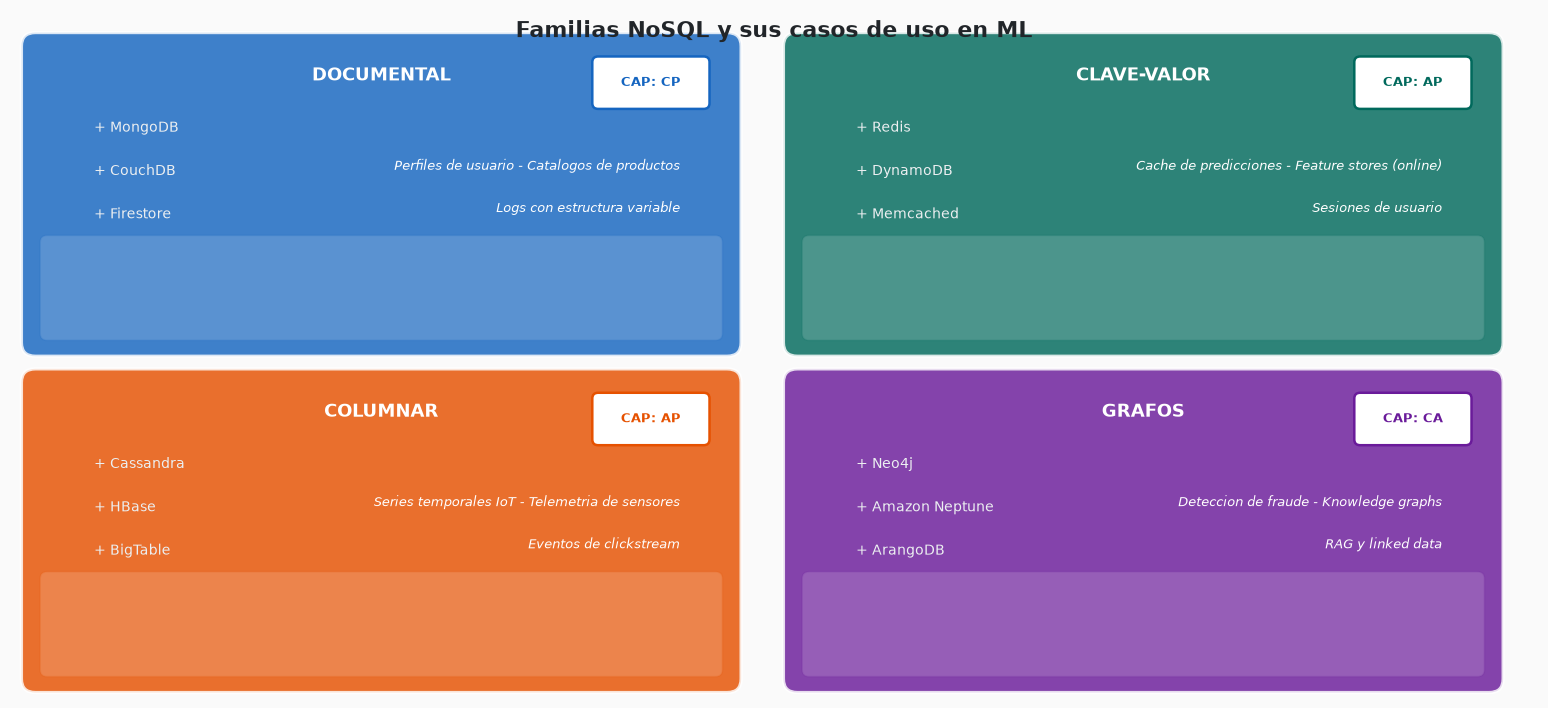

In [5]:
# ── Diagrama 2: Taxonomia NoSQL — 4 familias ─────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

ax.text(6.5, 5.78, 'Familias NoSQL y sus casos de uso en ML',
        ha='center', fontsize=15, fontweight='bold', color='#212529')

familias = [
    # (x, y, color, titulo, ejemplos, uso_linea1, uso_linea2, cap)
    (0.2,  3.1, '#1565C0', 'DOCUMENTAL',
     ['MongoDB', 'CouchDB', 'Firestore'],
     'Perfiles de usuario - Catalogos de productos',
     'Logs con estructura variable',
     'CP'),

    (6.7,  3.1, '#00695C', 'CLAVE-VALOR',
     ['Redis', 'DynamoDB', 'Memcached'],
     'Cache de predicciones - Feature stores (online)',
     'Sesiones de usuario',
     'AP'),

    (0.2,  0.15, '#E65100', 'COLUMNAR',
     ['Cassandra', 'HBase', 'BigTable'],
     'Series temporales IoT - Telemetria de sensores',
     'Eventos de clickstream',
     'AP'),

    (6.7,  0.15, '#6A1B9A', 'GRAFOS',
     ['Neo4j', 'Amazon Neptune', 'ArangoDB'],
     'Deteccion de fraude - Knowledge graphs',
     'RAG y linked data',
     'CA'),
]

for (x, y, color, titulo, ejemplos, uso1, uso2, cap) in familias:
    box = FancyBboxPatch((x, y), 5.9, 2.6,
                         boxstyle='round,pad=0.12',
                         facecolor=color, edgecolor='white', linewidth=2, alpha=0.82)
    ax.add_patch(box)

    ax.text(x + 2.95, y + 2.3, titulo,
            ha='center', fontsize=13, fontweight='bold', color='white')

    for j, ej in enumerate(ejemplos):
        ax.text(x + 0.5, y + 1.85 - j * 0.38, '+ ' + ej,
                ha='left', fontsize=10.5, color='#ECEFF1')

    ax.text(x + 5.5, y + 1.55, uso1,
            ha='right', va='center', fontsize=9.8, color='white', style='italic')
    ax.text(x + 5.5, y + 1.18, uso2,
            ha='right', va='center', fontsize=9.8, color='white', style='italic')

    cap_box = FancyBboxPatch((x + 4.8, y + 2.1), 0.9, 0.36,
                              boxstyle='round,pad=0.05',
                              facecolor='white', edgecolor=color, linewidth=1.5)
    ax.add_patch(cap_box)
    ax.text(x + 5.25, y + 2.28, 'CAP: ' + cap,
            ha='center', va='center', fontsize=9.5, fontweight='bold', color=color)

                              boxstyle='round,pad=0.06',
                              facecolor='white', edgecolor=color, linewidth=1, alpha=0.15)

plt.tight_layout()
plt.show()


In [6]:
# ── Ejemplo: base de datos documental (simulacion tipo MongoDB) ────────────
#
# MongoDB almacena "documentos" JSON/BSON. Cada documento puede tener
# campos distintos. Aqui simulamos con dicts de Python la misma logica.

print("=== Base de datos documental: catalogo de modelos ML ===")
print()

# Coleccion de documentos (equivale a una "tabla" en MongoDB)
modelos_ml = [
    {
        "_id": "model_001",
        "nombre": "XGBoost Churn v2.1",
        "tipo": "clasificacion",
        "metricas": {"roc_auc": 0.91, "f1": 0.84, "precision": 0.87},
        "features": ["dias_cliente", "n_pedidos", "gasto_total", "n_incidencias"],
        "hiperparametros": {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05},
        "fecha_entrenamiento": "2024-03-15",
        "activo": True
    },
    {
        "_id": "model_002",
        "nombre": "RandomForest Precios v1.0",
        "tipo": "regresion",
        "metricas": {"rmse": 12.4, "mae": 8.9, "r2": 0.88},
        "features": ["categoria", "peso_kg", "temporada", "competencia_precio"],
        "hiperparametros": {"n_estimators": 200, "max_depth": None},
        "fecha_entrenamiento": "2024-01-20",
        "activo": False,
        "nota": "Superado por LightGBM v2"   # campo opcional: solo en este doc
    },
    {
        "_id": "model_003",
        "nombre": "LightGBM Precios v2.0",
        "tipo": "regresion",
        "metricas": {"rmse": 9.1, "mae": 6.3, "r2": 0.93},
        "features": ["categoria", "peso_kg", "temporada", "competencia_precio", "stock"],
        "hiperparametros": {"num_leaves": 63, "learning_rate": 0.03, "n_estimators": 500},
        "fecha_entrenamiento": "2024-04-10",
        "activo": True
    }
]

# Consulta 1: filtrar por tipo (equivale a collection.find({tipo: "clasificacion"}))
print("Consulta: modelos activos de clasificacion")
print("-" * 50)
activos_clasificacion = [m for m in modelos_ml
                         if m["activo"] and m["tipo"] == "clasificacion"]
for m in activos_clasificacion:
    print(f"  {m['nombre']}  |  ROC-AUC: {m['metricas']['roc_auc']}")

# Consulta 2: extraer campo anidado (metricas) para comparar
print()
print("Comparativa de modelos activos por metrica principal:")
print("-" * 50)
for m in [m for m in modelos_ml if m["activo"]]:
    metrica_clave = "roc_auc" if m["tipo"] == "clasificacion" else "r2"
    print(f"  [{m['tipo'][:5]}] {m['nombre']:<30} {metrica_clave}: {m['metricas'][metrica_clave]}")

# Ventaja de los documentos: podemos convertir a DataFrame con json_normalize
df_modelos = pd.json_normalize(modelos_ml, sep='_')
print()
print("Columnas tras json_normalize (aplanado automatico de campos anidados):")
print([c for c in df_modelos.columns if 'metricas' in c or c in ['_id', 'nombre', 'activo']])


=== Base de datos documental: catalogo de modelos ML ===

Consulta: modelos activos de clasificacion
--------------------------------------------------
  XGBoost Churn v2.1  |  ROC-AUC: 0.91

Comparativa de modelos activos por metrica principal:
--------------------------------------------------
  [clasi] XGBoost Churn v2.1             roc_auc: 0.91
  [regre] LightGBM Precios v2.0          r2: 0.93

Columnas tras json_normalize (aplanado automatico de campos anidados):
['_id', 'nombre', 'activo', 'metricas_roc_auc', 'metricas_f1', 'metricas_precision', 'metricas_rmse', 'metricas_mae', 'metricas_r2']


In [7]:
# ── Ejemplo: almacen clave-valor (simulacion tipo Redis) ──────────────────
#
# Redis almacena pares {clave: valor}. Es extremadamente rapido (O(1)).
# En ML se usa como feature store online: el modelo pide las features
# de un usuario en tiempo real durante la inferencia.

print("=== Feature Store online (patron clave-valor tipo Redis) ===")
print()

class FeatureStoreSimulado:
    """Simulacion de un feature store tipo Redis para inferencia en tiempo real."""

    def __init__(self):
        self._store = {}

    def set_features(self, entidad_id: str, features: dict, ttl_s: int = None):
        """Guarda las features de una entidad. Clave = 'features:{entidad_id}' """
        clave = f"features:{entidad_id}"
        self._store[clave] = features
        print(f"  SET {clave} -> {len(features)} features guardadas")

    def get_features(self, entidad_id: str) -> dict:
        """Recupera las features para inferencia. Lookup O(1). """
        clave = f"features:{entidad_id}"
        return self._store.get(clave, {})

    def bulk_set(self, entidades: dict):
        """Escritura masiva (pipeline en Redis real). """
        for eid, feats in entidades.items():
            self.set_features(eid, feats)

    def __len__(self):
        return len(self._store)


fs = FeatureStoreSimulado()

# Escritura: el pipeline de entrenamiento calcula features y las escribe
print("1. Escritura de features (pipeline batch, cada 24h):")
fs.bulk_set({
    "cliente_1001": {"dias_cliente": 320, "n_pedidos": 12, "gasto_total": 890.5,
                     "ticket_medio": 74.2, "n_incidencias": 2, "pais_ES": 1},
    "cliente_1002": {"dias_cliente": 45,  "n_pedidos": 3,  "gasto_total": 120.0,
                     "ticket_medio": 40.0, "n_incidencias": 0, "pais_ES": 0},
    "cliente_1003": {"dias_cliente": 892, "n_pedidos": 67, "gasto_total": 4500.0,
                     "ticket_medio": 67.2, "n_incidencias": 5, "pais_ES": 1},
})

print()
print(f"   Feature store contiene {len(fs)} entidades.")

# Lectura: el modelo pide features cuando llega una solicitud de prediccion
print()
print("2. Lectura de features (API de inferencia, tiempo real):")
for cid in ["cliente_1001", "cliente_1002"]:
    feats = fs.get_features(cid)
    print(f"  GET {cid}: {feats}")

print()
print("-> Ventaja clave: el modelo no recalcula features en cada inferencia.")
print("   Las features se precalculan (batch) y se leen en O(1) desde Redis.")
print("   Esto evita el 'training-serving skew': mismas features en train y prod.")


=== Feature Store online (patron clave-valor tipo Redis) ===

1. Escritura de features (pipeline batch, cada 24h):
  SET features:cliente_1001 -> 6 features guardadas
  SET features:cliente_1002 -> 6 features guardadas
  SET features:cliente_1003 -> 6 features guardadas

   Feature store contiene 3 entidades.

2. Lectura de features (API de inferencia, tiempo real):
  GET cliente_1001: {'dias_cliente': 320, 'n_pedidos': 12, 'gasto_total': 890.5, 'ticket_medio': 74.2, 'n_incidencias': 2, 'pais_ES': 1}
  GET cliente_1002: {'dias_cliente': 45, 'n_pedidos': 3, 'gasto_total': 120.0, 'ticket_medio': 40.0, 'n_incidencias': 0, 'pais_ES': 0}

-> Ventaja clave: el modelo no recalcula features en cada inferencia.
   Las features se precalculan (batch) y se leen en O(1) desde Redis.
   Esto evita el 'training-serving skew': mismas features en train y prod.


In [8]:
# ── Ejemplo: grafo de conocimiento con NetworkX (patron tipo Neo4j) ────────
try:
    import networkx as nx

    print("=== Grafo de transacciones para deteccion de fraude ===")
    print()

    # En fraude financiero, las cuentas y transacciones forman un GRAFO.
    # Neo4j permite consultas como "encuentra ciclos de transferencias
    # entre cuentas en menos de 24 horas" que son imposibles en SQL.

    G = nx.DiGraph()

    # Nodos: cuentas bancarias
    cuentas = {
        'A001': {'tipo': 'personal', 'pais': 'ES', 'score_riesgo': 0.1},
        'A002': {'tipo': 'empresa',  'pais': 'ES', 'score_riesgo': 0.3},
        'A003': {'tipo': 'personal', 'pais': 'RU', 'score_riesgo': 0.8},
        'A004': {'tipo': 'empresa',  'pais': 'ES', 'score_riesgo': 0.2},
        'A005': {'tipo': 'personal', 'pais': 'RU', 'score_riesgo': 0.9},
    }
    for cuenta_id, attrs in cuentas.items():
        G.add_node(cuenta_id, **attrs)

    # Aristas: transferencias (origen -> destino, con importe)
    transferencias = [
        ('A001', 'A002', 1500),
        ('A002', 'A003', 1400),   # <- sospechoso: A002 reenvía casi todo
        ('A003', 'A005', 1380),   # <- sospechoso: cadena hacia RU
        ('A001', 'A004', 200),
        ('A004', 'A001', 195),    # <- ciclo pequeño entre A001 y A004
        ('A003', 'A001', 50),     # <- cierra el ciclo principal (fraude en anillo)
    ]
    for origen, destino, importe in transferencias:
        G.add_edge(origen, destino, importe=importe)

    # Features de grafo para ML
    print("Features de grafo extraidas para cada cuenta:")
    print(f"{'Cuenta':<8} {'In-degree':>10} {'Out-degree':>11} {'PageRank':>10} {'Riesgo':>8}")
    print("-" * 55)

    pagerank = nx.pagerank(G, alpha=0.85)
    for cuenta in sorted(G.nodes()):
        attrs = G.nodes[cuenta]
        pr = pagerank[cuenta]
        print(f"{cuenta:<8} {G.in_degree(cuenta):>10} {G.out_degree(cuenta):>11} "
              f"{pr:>10.4f} {attrs['score_riesgo']:>8.1f}")

    # Deteccion de ciclos (patron tipico de fraude en anillo)
    ciclos = list(nx.simple_cycles(G))
    print()
    print(f"Ciclos detectados en el grafo: {len(ciclos)}")
    for c in ciclos:
        print(f"  Ciclo: {' -> '.join(c)} -> {c[0]}")
    print()
    print("-> En Neo4j: MATCH p=(a)-[:TRANSFIERE*2..5]->(a) RETURN p")
    print("   Esta consulta de Cypher detecta ciclos en 1 linea.")
    print("   En SQL requeriria CTEs recursivos muy complejos.")

except ImportError:
    print("NetworkX no instalado. Para instalarlo: pip install networkx")
    print()
    print("NetworkX permite crear grafos en Python y extraer features como:")
    print("  - Centralidad (PageRank, betweenness, closeness)")
    print("  - Deteccion de comunidades (Louvain, Girvan-Newman)")
    print("  - Deteccion de ciclos (patrones de fraude en anillo)")
    print("  - Caminos mas cortos entre nodos")


=== Grafo de transacciones para deteccion de fraude ===

Features de grafo extraidas para cada cuenta:
Cuenta    In-degree  Out-degree   PageRank   Riesgo
-------------------------------------------------------
A001              2           2     0.2939      0.1
A002              1           1     0.1790      0.3
A003              1           2     0.2063      0.8
A004              1           1     0.1790      0.2
A005              1           0     0.1418      0.9

Ciclos detectados en el grafo: 2
  Ciclo: A001 -> A002 -> A003 -> A001
  Ciclo: A001 -> A004 -> A001

-> En Neo4j: MATCH p=(a)-[:TRANSFIERE*2..5]->(a) RETURN p
   Esta consulta de Cypher detecta ciclos en 1 linea.
   En SQL requeriria CTEs recursivos muy complejos.


---
## 2.3 Formatos de intercambio de datos: CSV, JSON y XML

Los formatos de intercambio son la "lingua franca" entre sistemas: se usan para exportar datos de una BD, compartir datasets entre organizaciones o alimentar pipelines ML desde ficheros.

### Comparativa de los tres formatos clásicos

| Característica | CSV | JSON | XML |
|---------------|-----|------|-----|
| **Legibilidad humana** | Alta | Alta | Media |
| **Soporte datos anidados** | No | Sí | Sí |
| **Tipado de datos** | No (todo texto) | Básico (número, bool, null) | No (todo texto) |
| **Tamaño relativo** | Pequeño | Medio | Grande (tags verbosos) |
| **Velocidad de parseo** | Muy rápida | Rápida | Lenta |
| **Estándar en ML** | Sí (datasets tabulares) | Sí (APIs, configs) | Legacy (sectores específicos) |
| **Pandas** | `read_csv()` | `read_json()` | (via ElementTree) |

> ⚠️ **Trampas comunes en CSV:** separador incorrecto, encoding (UTF-8 vs Latin-1), cabecera en fila incorrecta, tipos mezclados en columnas, valores nulos representados de formas distintas (`NaN`, `N/A`, `-`, `NULL`…). El 80 % del tiempo de preprocesado suele estar aquí.


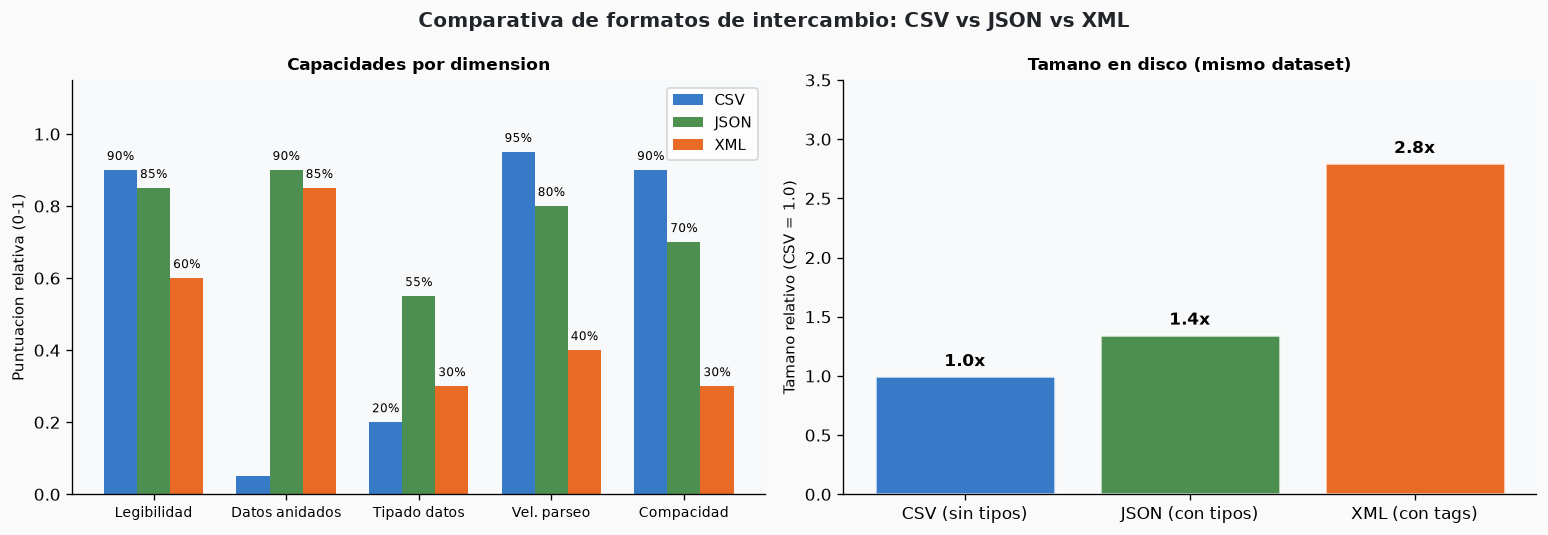

In [9]:
# ── Diagrama 3: Comparativa de formatos de intercambio ───────────────────
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Comparativa de formatos de intercambio: CSV vs JSON vs XML',
             fontsize=14, fontweight='bold', color='#212529')

# Puntuaciones representativas por dimension (0-1)
dimensiones    = ['Legibilidad', 'Datos anidados', 'Tipado datos',
                  'Vel. parseo', 'Compacidad']
csv_scores     = [0.90, 0.05, 0.20, 0.95, 0.90]
json_scores    = [0.85, 0.90, 0.55, 0.80, 0.70]
xml_scores     = [0.60, 0.85, 0.30, 0.40, 0.30]

x = np.arange(len(dimensiones))
w = 0.25
ax1 = axes[0]
bars_csv  = ax1.bar(x - w, csv_scores,  width=w, color='#1565C0', alpha=0.85, label='CSV')
bars_json = ax1.bar(x,     json_scores, width=w, color='#2E7D32', alpha=0.85, label='JSON')
bars_xml  = ax1.bar(x + w, xml_scores,  width=w, color='#E65100', alpha=0.85, label='XML')

ax1.set_ylim(0, 1.15)
ax1.set_xticks(x)
ax1.set_xticklabels(dimensiones, fontsize=10.5)
ax1.set_ylabel('Puntuacion relativa (0-1)', fontsize=11)
ax1.set_title('Capacidades por dimension', fontsize=12, fontweight='bold')
ax1.set_facecolor('#F8F9FA')
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(fontsize=11)

for bars, scores in [(bars_csv, csv_scores), (bars_json, json_scores), (bars_xml, xml_scores)]:
    for bar, v in zip(bars, scores):
        if v > 0.1:
            ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                     f'{v:.0%}', ha='center', va='bottom', fontsize=9)

# Grafico derecho: tamano relativo en el mismo dataset
ax2 = axes[1]
formatos  = ['CSV (sin tipos)', 'JSON (con tipos)', 'XML (con tags)']
tamanios  = [1.0, 1.35, 2.8]
colores_f = ['#1565C0', '#2E7D32', '#E65100']

bars2 = ax2.bar(formatos, tamanios, color=colores_f, alpha=0.85, edgecolor='white', linewidth=1.5)
ax2.set_ylim(0, 3.5)
ax2.set_ylabel('Tamano relativo (CSV = 1.0)', fontsize=11)
ax2.set_title('Tamano en disco (mismo dataset)', fontsize=12, fontweight='bold')
ax2.set_facecolor('#F8F9FA')
ax2.spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars2, tamanios):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
             f'{v:.1f}x', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [10]:
# ── CSV: lectura robusta con pandas ──────────────────────────────────────
#
# En la practica los CSV llegan con multitud de problemas. Aqui vemos
# como manejar los mas comunes.

import io

# CSV con problemas tipicos
csv_problematico = """id;nombre;edad;salario;ciudad;fecha_alta
1;Ana Garcia;32;28500,50;Madrid;15/01/2023
2;Blas;N/A;31000.00;Barcelona;01-06-2022
3;Clara O'Brien;29;"27.800,00";Sevilla;20/09/2023
4;David;;42000;Valencia;
5;Eva Mora;41;-;Malaga;05/11/2023
"""

print("CSV original (con separador ';', encoding mixto, nulos variados):")
print(csv_problematico)

# Lectura robusta
df = pd.read_csv(
    io.StringIO(csv_problematico),
    sep=';',                           # separador europeo
    na_values=['N/A', '-', ''],        # representaciones de nulo
    decimal=',',                       # decimal europeo (pero hay mezcla...)
    thousands='.',                     # separador de miles
    parse_dates=['fecha_alta'],        # parsear fechas automaticamente
    dayfirst=True,                     # formato DD/MM/YYYY
    dtype={'salario': str},            # leer salario como string primero
)

# Limpieza post-lectura del campo salario (mezcla de formatos)
def limpiar_salario(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace('.', '').replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return np.nan

df['salario'] = df['salario'].apply(limpiar_salario)

print("DataFrame despues de lectura robusta:")
print(df.to_string())
print()
print(f"Tipos de datos: {dict(df.dtypes)}")
print(f"Valores nulos por columna:")
print(df.isnull().sum().to_string())
print()
print("-> Siempre explorar el CSV crudo antes de asumir que read_csv() lo")
print("   procesa correctamente. El parametro na_values es tu mejor amigo.")


CSV original (con separador ';', encoding mixto, nulos variados):
id;nombre;edad;salario;ciudad;fecha_alta
1;Ana Garcia;32;28500,50;Madrid;15/01/2023
2;Blas;N/A;31000.00;Barcelona;01-06-2022
3;Clara O'Brien;29;"27.800,00";Sevilla;20/09/2023
4;David;;42000;Valencia;
5;Eva Mora;41;-;Malaga;05/11/2023

DataFrame despues de lectura robusta:
   id         nombre  edad    salario     ciudad  fecha_alta
0   1     Ana Garcia  32.0    28500.5     Madrid  15/01/2023
1   2           Blas   NaN  3100000.0  Barcelona  01-06-2022
2   3  Clara O'Brien  29.0    27800.0    Sevilla  20/09/2023
3   4          David   NaN    42000.0   Valencia         NaN
4   5       Eva Mora  41.0        NaN     Malaga  05/11/2023

Tipos de datos: {'id': dtype('int64'), 'nombre': dtype('O'), 'edad': dtype('float64'), 'salario': dtype('float64'), 'ciudad': dtype('O'), 'fecha_alta': dtype('O')}
Valores nulos por columna:
id            0
nombre        0
edad          2
salario       1
ciudad        0
fecha_alta    1

-> Sie

In [11]:
# ── JSON: formatos avanzados (NDJSON, arrays de objetos) ─────────────────

# NDJSON (Newline-Delimited JSON): un objeto JSON por linea.
# Es el formato estandar para logs, eventos de usuario, streaming outputs.
# Ventaja: se puede procesar linea a linea sin cargar todo en memoria.

ndjson_logs = """\
{"ts": "2024-05-01T10:00:01Z", "user": "u001", "event": "login",  "ok": true}
{"ts": "2024-05-01T10:00:45Z", "user": "u001", "event": "search", "query": "laptop", "resultados": 42}
{"ts": "2024-05-01T10:01:10Z", "user": "u001", "event": "click",  "item_id": "P-9821", "pos": 3}
{"ts": "2024-05-01T10:02:00Z", "user": "u002", "event": "login",  "ok": false, "motivo": "bad_password"}
{"ts": "2024-05-01T10:03:15Z", "user": "u001", "event": "compra", "item_id": "P-9821", "precio": 399.0}
"""

# Lectura de NDJSON linea a linea (eficiente para ficheros grandes)
registros = []
for linea in ndjson_logs.strip().split('\n'):
    registros.append(json.loads(linea))

df_logs = pd.DataFrame(registros)
df_logs['ts'] = pd.to_datetime(df_logs['ts'])
print("Logs en formato NDJSON convertidos a DataFrame:")
print(df_logs[['ts', 'user', 'event', 'ok', 'query', 'item_id']].to_string(index=False))

print()
print("Patron de sesion de u001 (secuencia de eventos en orden):")
sesion = df_logs[df_logs['user'] == 'u001'].sort_values('ts')
print(" -> ".join(sesion['event'].tolist()))
print()

# En pandas >= 1.0: pd.read_json con lines=True es equivalente
df_ndjson = pd.read_json(io.StringIO(ndjson_logs), lines=True)
print("Mismo resultado con pd.read_json(lines=True):")
print(df_ndjson[['ts', 'user', 'event']].to_string(index=False))


Logs en formato NDJSON convertidos a DataFrame:
                       ts user  event    ok  query item_id
2024-05-01 10:00:01+00:00 u001  login  True    NaN     NaN
2024-05-01 10:00:45+00:00 u001 search   NaN laptop     NaN
2024-05-01 10:01:10+00:00 u001  click   NaN    NaN  P-9821
2024-05-01 10:02:00+00:00 u002  login False    NaN     NaN
2024-05-01 10:03:15+00:00 u001 compra   NaN    NaN  P-9821

Patron de sesion de u001 (secuencia de eventos en orden):
login -> search -> click -> compra

Mismo resultado con pd.read_json(lines=True):
                  ts user  event
2024-05-01T10:00:01Z u001  login
2024-05-01T10:00:45Z u001 search
2024-05-01T10:01:10Z u001  click
2024-05-01T10:02:00Z u002  login
2024-05-01T10:03:15Z u001 compra


In [12]:
# ── XML: lectura con ElementTree ─────────────────────────────────────────
#
# XML es el formato obligatorio en sectores como sanidad (HL7/FHIR),
# administracion publica (facturacion electronica), finanzas (XBRL)
# y automatizacion industrial (OPC-UA).

xml_catalogo = """<?xml version="1.0" encoding="UTF-8"?>
<catalogo>
  <producto id="P001" categoria="electronica">
    <nombre>Laptop Pro X</nombre>
    <precio moneda="EUR">1299.99</precio>
    <stock>42</stock>
    <especificaciones>
      <ram>16GB</ram>
      <almacenamiento>512GB SSD</almacenamiento>
      <cpu>Intel Core i7</cpu>
    </especificaciones>
  </producto>
  <producto id="P002" categoria="accesorios">
    <nombre>Raton Ergonomico</nombre>
    <precio moneda="EUR">45.50</precio>
    <stock>180</stock>
    <especificaciones>
      <conexion>Bluetooth</conexion>
      <dpi>1600</dpi>
    </especificaciones>
  </producto>
  <producto id="P003" categoria="electronica">
    <nombre>Monitor 4K</nombre>
    <precio moneda="EUR">389.00</precio>
    <stock>15</stock>
    <especificaciones>
      <pulgadas>27</pulgadas>
      <resolucion>3840x2160</resolucion>
      <panel>IPS</panel>
    </especificaciones>
  </producto>
</catalogo>"""

root = ET.fromstring(xml_catalogo)

# Convertir a DataFrame: iterar sobre elementos del XML
registros_xml = []
for prod in root.findall('producto'):
    fila = {
        'id':        prod.get('id'),
        'categoria': prod.get('categoria'),
        'nombre':    prod.findtext('nombre'),
        'precio':    float(prod.findtext('precio')),
        'stock':     int(prod.findtext('stock')),
    }
    # Aplanar especificaciones (campos variables segun producto)
    specs = prod.find('especificaciones')
    if specs is not None:
        for spec in specs:
            fila[f'spec_{spec.tag}'] = spec.text
    registros_xml.append(fila)

df_xml = pd.DataFrame(registros_xml)
print("Catalogo XML convertido a DataFrame:")
print(df_xml.to_string(index=False))
print()
print("Columnas con NaN = especificaciones que no existen en todos los productos.")
print("Esto es tipico al aplanar XML/JSON con esquema variable.")
print()
print(f"Productos electronicos: {len(df_xml[df_xml['categoria']=='electronica'])}")
print(f"Valor total en stock:   {(df_xml['precio'] * df_xml['stock']).sum():.2f} EUR")


Catalogo XML convertido a DataFrame:
  id   categoria           nombre  precio  stock spec_ram spec_almacenamiento      spec_cpu spec_conexion spec_dpi spec_pulgadas spec_resolucion spec_panel
P001 electronica     Laptop Pro X 1299.99     42     16GB           512GB SSD Intel Core i7           NaN      NaN           NaN             NaN        NaN
P002  accesorios Raton Ergonomico   45.50    180      NaN                 NaN           NaN     Bluetooth     1600           NaN             NaN        NaN
P003 electronica       Monitor 4K  389.00     15      NaN                 NaN           NaN           NaN      NaN            27       3840x2160        IPS

Columnas con NaN = especificaciones que no existen en todos los productos.
Esto es tipico al aplanar XML/JSON con esquema variable.

Productos electronicos: 2
Valor total en stock:   68624.58 EUR


---
## 2.4 Formatos orientados a ML y Big Data: Parquet, Arrow y HDF5

Los formatos clásicos (CSV, JSON, XML) fueron diseñados para intercambio, no para análisis a gran escala. Los formatos modernos priorizan:

- **Almacenamiento columnar**: para acceder solo a las columnas necesarias sin leer toda la fila.
- **Compresión nativa**: reducir el tamaño sin sacrificar velocidad de lectura.
- **Esquema integrado**: los tipos de datos se guardan junto con los datos (no hay ambigüedad).
- **Lectura parcial (pushdown)**: filtrar filas antes de descomprimirlas.

### Los tres grandes formatos para ML

| Formato | Orientación | Soporte en pandas | Caso de uso principal en ML |
|---------|------------|-------------------|----------------------------|
| **Parquet** | Disco columnar | `read_parquet()` / `to_parquet()` | Almacenamiento de datasets de entrenamiento |
| **Apache Arrow** | Memoria columnar | `pa.Table`, `pa.RecordBatch` | Transferencia zero-copy entre frameworks |
| **HDF5** | Arrays numéricos | `pd.read_hdf()` / `h5py` | Pesos de modelos, matrices densas, datos científicos |

> 💡 **Parquet es el estándar de facto** en pipelines ML modernos: S3 en Parquet + pandas/Spark/DuckDB es la combinación más común en data lakes. Delta Lake e Apache Iceberg añaden transacciones ACID sobre Parquet.


In [13]:
# ── Benchmark real: CSV vs Parquet vs Arrow — tamano y velocidad ──────────
#
# Generamos un dataset sintetico de 500.000 filas y lo guardamos
# en distintos formatos. Medimos tamano en disco y tiempo de lectura.

try:
    import pyarrow as pa
    import pyarrow.parquet as pq
    HAS_ARROW = True
except ImportError:
    HAS_ARROW = False

rng = np.random.default_rng(0)
N = 500_000
df_bench = pd.DataFrame({
    'id':          np.arange(N),
    'categoria':   rng.choice(['A', 'B', 'C', 'D', 'E'], N),
    'valor_1':     rng.normal(100, 15, N).round(4),
    'valor_2':     rng.exponential(50, N).round(4),
    'valor_3':     rng.integers(0, 10_000, N),
    'flag':        rng.integers(0, 2, N).astype(bool),
    'texto_corto': rng.choice(['alpha', 'beta', 'gamma', 'delta', 'epsilon'], N),
})
print(f"Dataset de benchmark: {N:,} filas x {df_bench.shape[1]} columnas")

rutas = {
    'CSV (sin comprimir)':    'bench.csv',
    'CSV (gzip)':             'bench.csv.gz',
    'Parquet (snappy)':       'bench.parquet',
    'Parquet (gzip)':         'bench_gz.parquet',
}
if HAS_ARROW:
    rutas['Arrow IPC'] = 'bench.arrow'

resultados = {}

# Escritura
df_bench.to_csv('bench.csv', index=False)
df_bench.to_csv('bench.csv.gz', index=False, compression='gzip')
df_bench.to_parquet('bench.parquet', compression='snappy', index=False)
df_bench.to_parquet('bench_gz.parquet', compression='gzip', index=False)
if HAS_ARROW:
    table = pa.Table.from_pandas(df_bench)
    with pa.ipc.new_file('bench.arrow', table.schema) as writer:
        writer.write_table(table)

# Medicion
for nombre, ruta in rutas.items():
    if not os.path.exists(ruta):
        continue
    tamano_mb = os.path.getsize(ruta) / 1_048_576

    t0 = time.perf_counter()
    if ruta.endswith('.csv') or ruta.endswith('.csv.gz'):
        _ = pd.read_csv(ruta)
    elif ruta.endswith('.parquet'):
        _ = pd.read_parquet(ruta)
    elif ruta.endswith('.arrow') and HAS_ARROW:
        with pa.ipc.open_file(ruta) as f:
            _ = f.read_pandas()
    t_read = (time.perf_counter() - t0) * 1000

    resultados[nombre] = {'tamano_mb': tamano_mb, 't_lectura_ms': t_read}

# Tabla comparativa
print()
print(f"{'Formato':<25} {'Tamano (MB)':>12} {'Lectura (ms)':>13} {'Ratio tamano':>13}")
print("-" * 68)
csv_size = resultados['CSV (sin comprimir)']['tamano_mb']
for nombre, vals in resultados.items():
    ratio = vals['tamano_mb'] / csv_size
    print(f"{nombre:<25} {vals['tamano_mb']:>12.1f} {vals['t_lectura_ms']:>13.0f} "
          f"{ratio:>12.2f}x")


Dataset de benchmark: 500,000 filas x 7 columnas

Formato                    Tamano (MB)  Lectura (ms)  Ratio tamano
--------------------------------------------------------------------
CSV (sin comprimir)               20.3           405         1.00x
CSV (gzip)                         6.9           440         0.34x
Parquet (snappy)                   9.7           112         0.48x
Parquet (gzip)                     6.5            86         0.32x
Arrow IPC                         22.1            71         1.09x


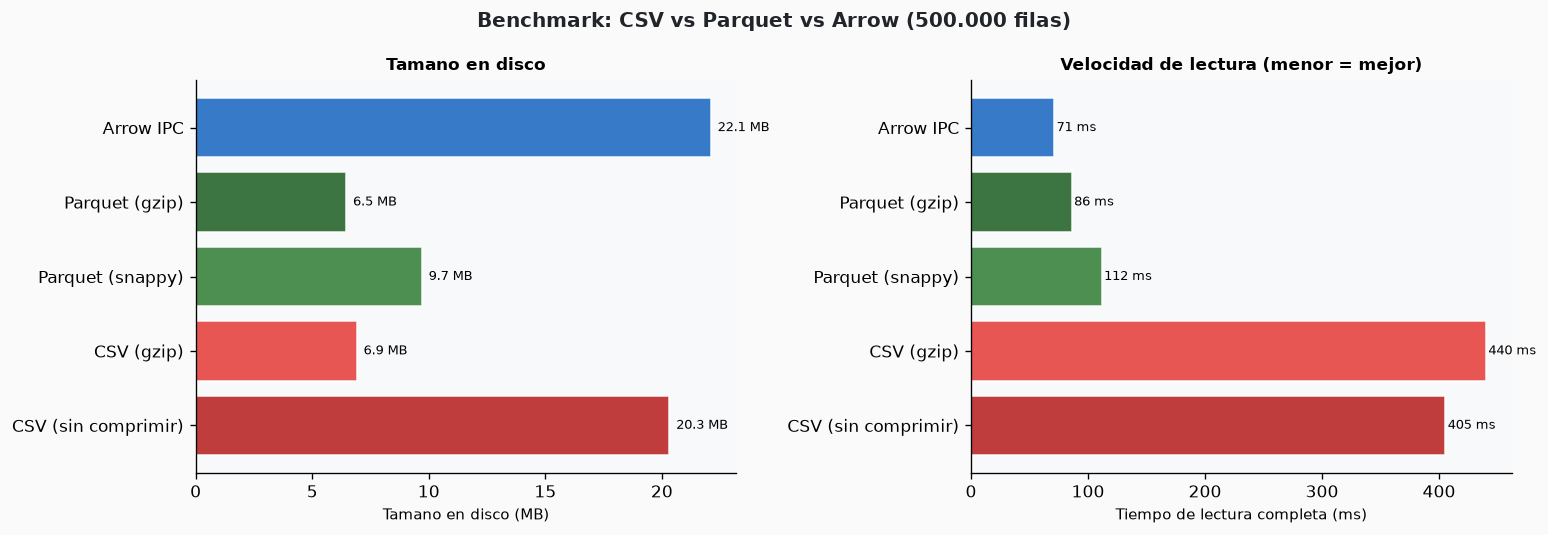

In [14]:
# ── Grafico del benchmark ────────────────────────────────────────────────
if resultados:
    nombres   = list(resultados.keys())
    tamanios  = [resultados[n]['tamano_mb'] for n in nombres]
    tiempos   = [resultados[n]['t_lectura_ms'] for n in nombres]

    colores_bench = {
        'CSV (sin comprimir)':  '#B71C1C',
        'CSV (gzip)':           '#E53935',
        'Parquet (snappy)':     '#2E7D32',
        'Parquet (gzip)':       '#1B5E20',
        'Arrow IPC':            '#1565C0',
    }
    bar_colors = [colores_bench.get(n, '#546E7A') for n in nombres]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor('#FAFAFA')
    fig.suptitle('Benchmark: CSV vs Parquet vs Arrow (500.000 filas)',
                 fontsize=14, fontweight='bold', color='#212529')

    # Tamano en disco
    bars1 = ax1.barh(nombres, tamanios, color=bar_colors, alpha=0.85, edgecolor='white')
    ax1.set_xlabel('Tamano en disco (MB)', fontsize=11)
    ax1.set_title('Tamano en disco', fontsize=12, fontweight='bold')
    ax1.set_facecolor('#F8F9FA')
    ax1.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars1, tamanios):
        ax1.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{v:.1f} MB', va='center', fontsize=10)

    # Tiempo de lectura
    bars2 = ax2.barh(nombres, tiempos, color=bar_colors, alpha=0.85, edgecolor='white')
    ax2.set_xlabel('Tiempo de lectura completa (ms)', fontsize=11)
    ax2.set_title('Velocidad de lectura (menor = mejor)', fontsize=12, fontweight='bold')
    ax2.set_facecolor('#F8F9FA')
    ax2.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars2, tiempos):
        ax2.text(v + 2, bar.get_y() + bar.get_height() / 2,
                 f'{v:.0f} ms', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No hay resultados de benchmark disponibles.")


In [15]:
# ── Apache Arrow: columnar en memoria y transferencia zero-copy ───────────
try:
    import pyarrow as pa
    import pyarrow.compute as pc

    print("=== Apache Arrow: columnar en memoria ===")
    print()

    # Arrow Table desde pandas (copia minima de datos)
    t0 = time.perf_counter()
    tabla = pa.Table.from_pandas(df_bench)
    t_conv = (time.perf_counter() - t0) * 1000
    print(f"Conversion pandas -> Arrow: {t_conv:.1f} ms")
    print(f"Schema Arrow: {tabla.schema}")
    print()

    # Operacion columnar sin conversion: suma de valor_1 por categoria
    t0 = time.perf_counter()
    # Filtrar solo categoria 'A' usando Arrow compute
    mask     = pc.equal(tabla.column('categoria'), 'A')
    tabla_a  = tabla.filter(mask)
    suma_a   = pc.sum(tabla_a.column('valor_1')).as_py()
    t_arrow  = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    suma_pd  = df_bench.loc[df_bench['categoria'] == 'A', 'valor_1'].sum()
    t_pandas = (time.perf_counter() - t0) * 1000

    print(f"Suma valor_1 (cat=A):")
    print(f"  Arrow:  {suma_a:.4f}  en {t_arrow:.1f} ms")
    print(f"  pandas: {suma_pd:.4f}  en {t_pandas:.1f} ms")
    print()

    # Slicing zero-copy: no copia datos
    columna_val1 = tabla.column('valor_1')
    slice_val1   = columna_val1.slice(0, 5)
    print(f"Primeros 5 valores de valor_1 (zero-copy slice): {slice_val1.to_pylist()}")
    print()
    print("-> Zero-copy: pandas y Arrow pueden compartir el mismo buffer de memoria.")
    print("   Esto es clave en pipelines donde intervienen Spark, Dask o Ray.")

except ImportError:
    print("PyArrow no instalado. Para instalarlo: pip install pyarrow")
    print()
    print("Apache Arrow define un formato columnar en memoria estandar.")
    print("Permite transferencia de datos sin copias entre:")
    print("  pandas <-> Spark <-> Dask <-> DuckDB <-> Polars <-> Ray")


=== Apache Arrow: columnar en memoria ===

Conversion pandas -> Arrow: 67.6 ms
Schema Arrow: id: int64
categoria: string
valor_1: double
valor_2: double
valor_3: int64
flag: bool
texto_corto: string
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 1067

Suma valor_1 (cat=A):
  Arrow:  9983141.7906  en 17.5 ms
  pandas: 9983141.7906  en 29.8 ms

Primeros 5 valores de valor_1 (zero-copy slice): [86.365, 105.5361, 113.4853, 106.9961, 116.7458]

-> Zero-copy: pandas y Arrow pueden compartir el mismo buffer de memoria.
   Esto es clave en pipelines donde intervienen Spark, Dask o Ray.


In [16]:
# ── HDF5: almacenamiento de arrays numericos grandes con h5py ─────────────
try:
    import h5py

    print("=== HDF5: almacenamiento jerarquico de arrays ===")
    print()

    # HDF5 organiza los datos en grupos (directorios) y datasets (arrays).
    # Es el formato estandar para pesos de modelos (Keras .h5),
    # datos climaticos, astronomia, neurociencia.

    ruta_h5 = 'experimento_ml.h5'

    # ── Escritura ──
    with h5py.File(ruta_h5, 'w') as f:
        # Grupo para datos de entrenamiento
        grp_train = f.create_group('datos/entrenamiento')
        rng_h5 = np.random.default_rng(99)
        X_train = rng_h5.normal(0, 1, (10_000, 20)).astype(np.float32)
        y_train = rng_h5.integers(0, 3, 10_000)

        ds_X = grp_train.create_dataset('X', data=X_train,
                                        compression='gzip', compression_opts=4)
        ds_y = grp_train.create_dataset('y', data=y_train)

        # Metadatos como atributos
        ds_X.attrs['descripcion'] = '10.000 muestras x 20 features (float32)'
        ds_X.attrs['normalizacion'] = 'StandardScaler (media=0, std=1)'
        f.attrs['proyecto']    = 'Clasificacion multiclase - prueba UD1'
        f.attrs['fecha']       = '2026-08-14'
        f.attrs['autor']       = 'ETCDFM 2026-27'

        # Grupo para resultados del experimento
        grp_res = f.create_group('resultados')
        grp_res.create_dataset('accuracies', data=np.array([0.78, 0.82, 0.85, 0.87, 0.88]))
        grp_res.create_dataset('losses',     data=np.array([1.20, 0.95, 0.78, 0.65, 0.58]))

    tamano_kb = os.path.getsize(ruta_h5) / 1024
    print(f"Fichero HDF5 creado: {tamano_kb:.1f} KB")
    print()

    # ── Lectura selectiva (solo una parte) ──
    with h5py.File(ruta_h5, 'r') as f:
        # Introspection del fichero
        print("Estructura del fichero HDF5:")
        f.visititems(lambda name, obj:
            print(f"  /{name}  [{type(obj).__name__}]"))

        print()
        print("Atributos del fichero:")
        for k, v in f.attrs.items():
            print(f"  {k}: {v}")

        # Lectura parcial: solo las primeras 5 filas de X (sin cargar todo)
        X_parcial = f['datos/entrenamiento/X'][:5, :]
        print()
        print(f"Primeras 5 filas de X (lectura parcial, shape: {X_parcial.shape}):")
        print(np.round(X_parcial[:, :6], 3))  # primeras 6 columnas

        accs = f['resultados/accuracies'][:]
        print()
        print(f"Curva de accuracy: {accs}")
        print(f"Mejor accuracy:    {accs.max():.2%}")

except ImportError:
    print("h5py no instalado. Para instalarlo: pip install h5py")
    print()
    print("HDF5 (Hierarchical Data Format v5) se usa para:")
    print("  - Guardar pesos de redes neuronales (Keras: model.save('model.h5'))")
    print("  - Datasets cientificos grandes (NetCDF, datos climaticos, MRI)")
    print("  - Arrays numericos con metadatos y compresion integrada")
    print("  - Estructura jerarquica: grupos = directorios, datasets = arrays")


=== HDF5: almacenamiento jerarquico de arrays ===

Fichero HDF5 creado: 824.2 KB

Estructura del fichero HDF5:
  /datos  [Group]
  /datos/entrenamiento  [Group]
  /datos/entrenamiento/X  [Dataset]
  /datos/entrenamiento/y  [Dataset]
  /resultados  [Group]
  /resultados/accuracies  [Dataset]
  /resultados/losses  [Dataset]

Atributos del fichero:
  autor: ETCDFM 2026-27
  fecha: 2026-08-14
  proyecto: Clasificacion multiclase - prueba UD1

Primeras 5 filas de X (lectura parcial, shape: (5, 20)):
[[ 0.082 -0.464  0.051  0.686 -1.757  1.684]
 [ 0.722 -0.352  0.673  0.141  0.463 -1.518]
 [-0.404  1.471 -0.748  1.211  0.293  1.697]
 [-0.674  0.108  1.52   0.269  0.091  0.348]
 [-0.08  -0.072  0.189 -0.74   0.017 -1.239]]

Curva de accuracy: [0.78 0.82 0.85 0.87 0.88]
Mejor accuracy:    88.00%


---
## 2.5 Sistemas IoT y SCADA: datos industriales para ML

Los sistemas **SCADA** (Supervisory Control and Data Acquisition) y las redes **IoT** son la principal fuente de datos en **ML industrial** (mantenimiento predictivo, detección de anomalías, optimización de procesos).

### Arquitectura en capas del mundo industrial

```
Nivel 4: Empresa / Nube / ML
   MES, ERP, Data Lake, modelos de prediccion
Nivel 3: Supervision (SCADA / Historian)
   SCADA software, BD de series temporales (InfluxDB, TimescaleDB)
Nivel 2: Control (PLCs / RTUs)
   Logica de control, alarmas, setpoints
Nivel 1: Campo (sensores / actuadores)
   Temperatura, presion, vibracion, caudal, corriente
```

### Protocolos y formatos de datos

| Protocolo | Capa | Datos que genera | Formato habitual |
|-----------|------|-----------------|-----------------|
| **OPC-UA** | 2-3 | Valores de tags con timestamp | XML / binario |
| **MQTT** | 1-3 | Mensajes ligeros (IoT) | JSON / binario |
| **Modbus** | 1-2 | Registros numéricos de PLCs | Binario |
| **IEC 61850** | 2-3 | Subestaciones eléctricas | XML (SCL) |

### Tipo de datos que generan: **series temporales**

Cada sensor produce una lectura cada N segundos/ms: `{timestamp, sensor_id, valor}`. Las características clave son:
- **Alta frecuencia**: 1 Hz a 10 kHz (vibración de motor).
- **Multivariate**: decenas/cientos de sensores simultáneos.
- **Anomalías raras**: la tasa de fallos es <<1 % → dataset muy desbalanceado.


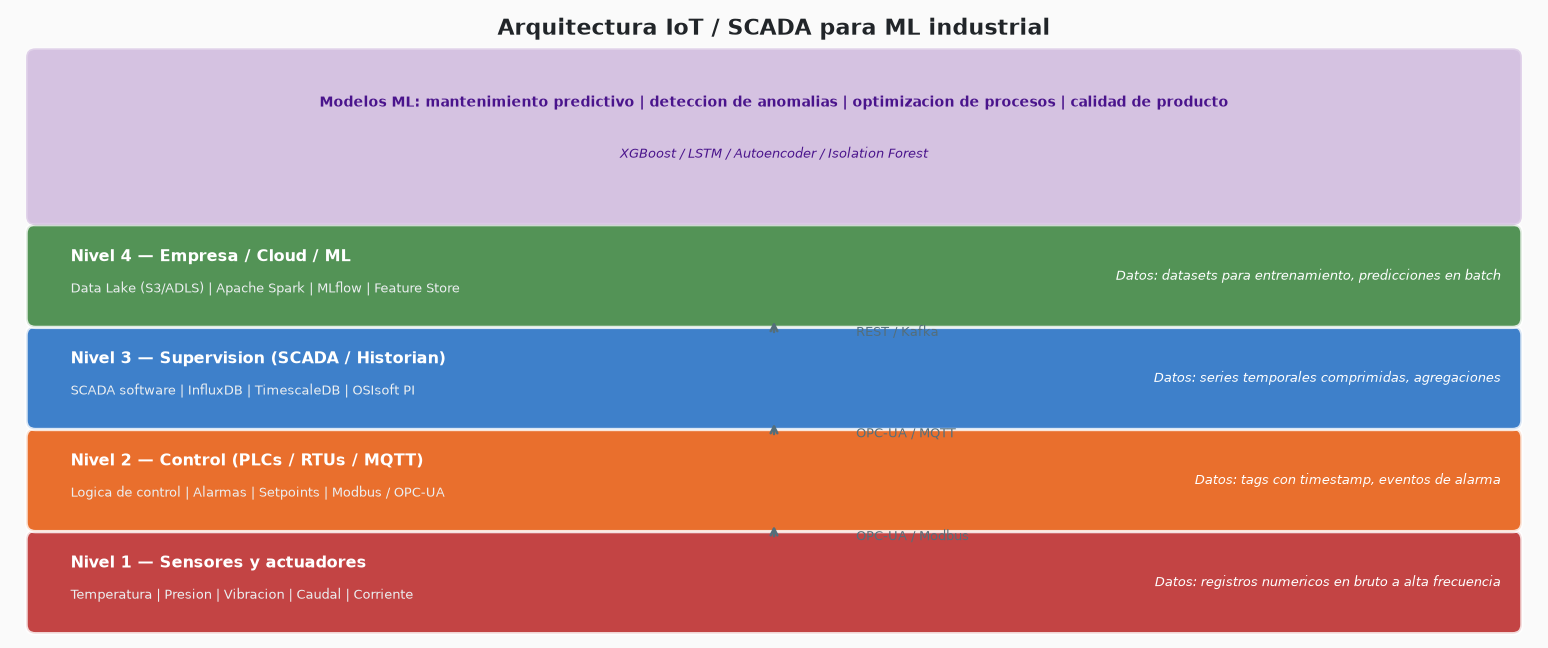

In [17]:
# ── Diagrama 5: Arquitectura IoT/SCADA en capas ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5.5)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

ax.text(6.5, 5.3, 'Arquitectura IoT / SCADA para ML industrial',
        ha='center', fontsize=15, fontweight='bold', color='#212529')

capas = [
    # (y_base, height, color, titulo, descripcion, lado_derecho)
    (0.1, 0.75, '#B71C1C',
     'Nivel 1 — Sensores y actuadores',
     'Temperatura | Presion | Vibracion | Caudal | Corriente',
     'Datos: registros numericos en bruto a alta frecuencia'),

    (1.0, 0.75, '#E65100',
     'Nivel 2 — Control (PLCs / RTUs / MQTT)',
     'Logica de control | Alarmas | Setpoints | Modbus / OPC-UA',
     'Datos: tags con timestamp, eventos de alarma'),

    (1.9, 0.75, '#1565C0',
     'Nivel 3 — Supervision (SCADA / Historian)',
     'SCADA software | InfluxDB | TimescaleDB | OSIsoft PI',
     'Datos: series temporales comprimidas, agregaciones'),

    (2.8, 0.75, '#2E7D32',
     'Nivel 4 — Empresa / Cloud / ML',
     'Data Lake (S3/ADLS) | Apache Spark | MLflow | Feature Store',
     'Datos: datasets para entrenamiento, predicciones en batch'),
]

for (y, h, color, titulo, desc, derecha) in capas:
    box = FancyBboxPatch((0.2, y), 12.6, h,
                         boxstyle='round,pad=0.08',
                         facecolor=color, edgecolor='white', linewidth=2, alpha=0.82)
    ax.add_patch(box)
    ax.text(0.5, y + h * 0.72, titulo,
            ha='left', va='center', fontsize=11.5, fontweight='bold', color='white')
    ax.text(0.5, y + h * 0.35, desc,
            ha='left', va='center', fontsize=10, color='#ECEFF1')
    ax.text(12.7, y + h * 0.5, derecha,
            ha='right', va='center', fontsize=9.5, color='white', style='italic')

# Flechas entre capas
for y_flecha in [0.85, 1.75, 2.65]:
    ax.annotate('', xy=(6.5, y_flecha + 0.15), xytext=(6.5, y_flecha),
                arrowprops=dict(arrowstyle='->', color='#546E7A', lw=1.5))

# Protocolo entre capas
protos = [(0.88, 'OPC-UA / Modbus'), (1.78, 'OPC-UA / MQTT'), (2.68, 'REST / Kafka')]
for y_p, proto in protos:
    ax.text(7.2, y_p, proto, ha='left', va='center', fontsize=9.5, color='#546E7A')

# Banda de ML
ml_box = FancyBboxPatch((0.2, 3.7), 12.6, 1.4,
                         boxstyle='round,pad=0.08',
                         facecolor='#6A1B9A', edgecolor='white', linewidth=2, alpha=0.25)
ax.add_patch(ml_box)
ax.text(6.5, 4.7, 'Modelos ML: mantenimiento predictivo | deteccion de anomalias | '
        'optimizacion de procesos | calidad de producto',
        ha='center', va='center', fontsize=10.5, color='#4A148C', fontweight='bold')
ax.text(6.5, 4.25, 'XGBoost / LSTM / Autoencoder / Isolation Forest',
        ha='center', va='center', fontsize=10, color='#4A148C', style='italic')

plt.tight_layout()
plt.show()


In [18]:
# ── Simulacion de datos SCADA: serie temporal multivariada de una turbina ─
import random
from collections import deque

random.seed(42)
np.random.seed(42)

# Parametros de la planta: turbina de vapor en central electrica
SENSORES = {
    'temp_entrada_c':   {'media': 450, 'std': 8,   'unidad': 'C'},
    'temp_salida_c':    {'media': 120, 'std': 5,   'unidad': 'C'},
    'presion_bar':      {'media': 32,  'std': 0.8, 'unidad': 'bar'},
    'vibracion_mms':    {'media': 2.5, 'std': 0.4, 'unidad': 'mm/s'},
    'rpm':              {'media': 3000,'std': 15,  'unidad': 'rpm'},
    'potencia_mw':      {'media': 50,  'std': 3,   'unidad': 'MW'},
}

# Generamos 30 minutos de datos a 1 Hz = 1800 lecturas
N_LECTURAS = 1800
timestamps  = pd.date_range('2026-05-14 08:00:00', periods=N_LECTURAS, freq='s')

filas = []
# Inyectamos un fallo gradual en vibracion entre t=900 y t=1200 (5-20 min)
for i, ts in enumerate(timestamps):
    fila = {'timestamp': ts, 'turbina_id': 'TB-03'}
    for sensor, params in SENSORES.items():
        val = np.random.normal(params['media'], params['std'])
        # Simular degradacion progresiva de vibracion (rodamiento deteriorado)
        if sensor == 'vibracion_mms' and 900 <= i < 1200:
            val += (i - 900) * 0.012   # aumento lineal de 3.6 mm/s en 5 min
        elif sensor == 'vibracion_mms' and i >= 1200:
            val += 3.6 + np.random.normal(0, 0.3)  # vibracion elevada estable
        fila[sensor] = round(val, 3)
    filas.append(fila)

df_scada = pd.DataFrame(filas)
df_scada = df_scada.set_index('timestamp')

print("Serie temporal SCADA: turbina TB-03 (primeras 5 lecturas):")
print(df_scada.head().to_string())
print(f"\nShape total: {df_scada.shape} | Duracion: {N_LECTURAS} segundos (30 min)")
print()

# Estadisticas descriptivas por periodo (normal vs anomalia vs critico)
df_scada['periodo'] = pd.cut(
    np.arange(N_LECTURAS), bins=[0, 900, 1200, 1800],
    labels=['Normal (0-15min)', 'Degradacion (15-20min)', 'Critico (20-30min)']
)
print("Estadisticas de vibracion por periodo:")
resumen = df_scada.groupby('periodo', observed=True)['vibracion_mms'].agg(
    media='mean', std='std', max='max'
).round(3)
print(resumen.to_string())


Serie temporal SCADA: turbina TB-03 (primeras 5 lecturas):
                    turbina_id  temp_entrada_c  temp_salida_c  presion_bar  vibracion_mms       rpm  potencia_mw
timestamp                                                                                                       
2026-05-14 08:00:00      TB-03         453.974        119.309       32.518          3.109  2996.488       49.298
2026-05-14 08:00:01      TB-03         462.634        123.837       31.624          2.717  2993.049       48.603
2026-05-14 08:00:02      TB-03         451.936        110.434       30.620          2.275  2984.808       50.943
2026-05-14 08:00:03      TB-03         442.736        112.938       33.173          2.410  3001.013       45.726
2026-05-14 08:00:04      TB-03         445.645        120.555       31.079          2.650  2990.990       49.125

Shape total: (1800, 7) | Duracion: 1800 segundos (30 min)

Estadisticas de vibracion por periodo:
                        media    std    max
periodo

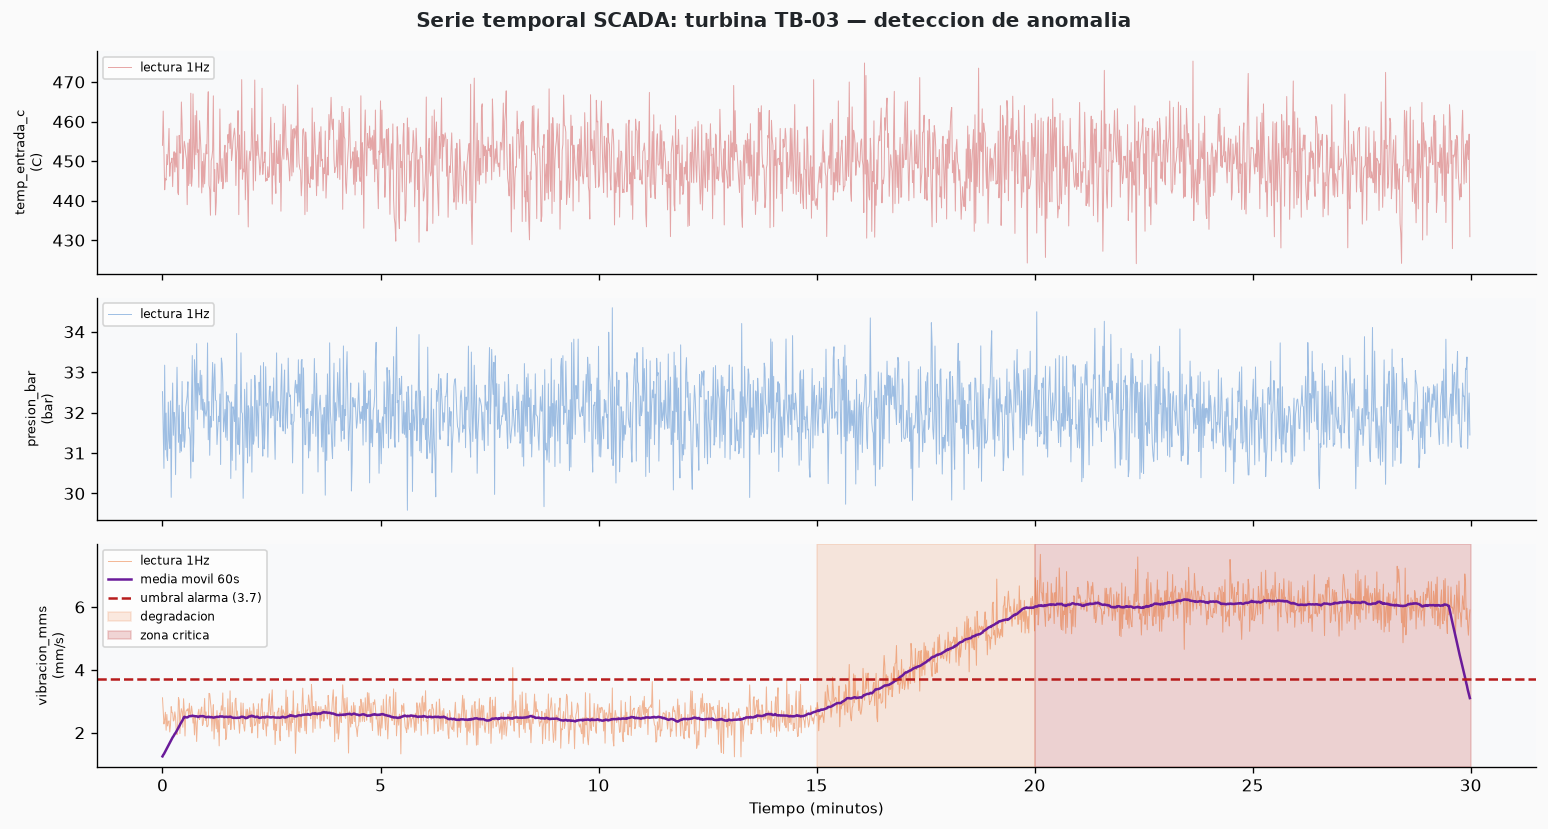


Features tipicas para un modelo de deteccion de anomalias en series temporales:

  Estadisticas de ventana (rolling window):
    - media movil, desviacion tipica, min, max en ventanas de 10s, 60s, 5min

  Features de frecuencia (FFT):
    - amplitud de las frecuencias dominantes (vibracion de rodamientos)

  Features cruzadas:
    - diferencia temp_entrada - temp_salida (eficiencia termica)
    - vibracion / rpm (vibracion normalizada por velocidad)

  Modelos habituales:
    - Isolation Forest, Autoencoder (deteccion no supervisada)
    - LSTM, Temporal Fusion Transformer (prediccion de series temporales)


In [19]:
# ── Visualizacion de la serie temporal y extraccion de features para ML ───
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Serie temporal SCADA: turbina TB-03 — deteccion de anomalia',
             fontsize=14, fontweight='bold', color='#212529')

t = np.arange(N_LECTURAS) / 60   # tiempo en minutos

# Calcular media movil de vibracion (ventana 60s)
vibracion = df_scada['vibracion_mms'].values
ventana   = 60
media_mov = np.convolve(vibracion, np.ones(ventana) / ventana, mode='same')
umbral    = SENSORES['vibracion_mms']['media'] + 3 * SENSORES['vibracion_mms']['std']

for ax, sensor, color in [
    (axes[0], 'temp_entrada_c', '#C62828'),
    (axes[1], 'presion_bar',    '#1565C0'),
    (axes[2], 'vibracion_mms',  '#E65100'),
]:
    vals = df_scada[sensor].values
    ax.plot(t, vals, alpha=0.4, color=color, linewidth=0.6, label='lectura 1Hz')
    if sensor == 'vibracion_mms':
        ax.plot(t, media_mov, color='#6A1B9A', linewidth=1.5,
                label='media movil 60s')
        ax.axhline(umbral, color='#B71C1C', linewidth=1.5,
                   linestyle='--', label=f'umbral alarma ({umbral:.1f})')
        # Sombrear zona anomala
        ax.axvspan(15, 20, alpha=0.12, color='#E65100', label='degradacion')
        ax.axvspan(20, 30, alpha=0.18, color='#B71C1C', label='zona critica')
    ax.set_ylabel(f"{sensor}\n({SENSORES[sensor]['unidad']})", fontsize=10)
    ax.set_facecolor('#F8F9FA')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9, loc='upper left')

axes[2].set_xlabel('Tiempo (minutos)', fontsize=11)
plt.tight_layout()
plt.show()

print()
print("Features tipicas para un modelo de deteccion de anomalias en series temporales:")
print()
print("  Estadisticas de ventana (rolling window):")
print("    - media movil, desviacion tipica, min, max en ventanas de 10s, 60s, 5min")
print()
print("  Features de frecuencia (FFT):")
print("    - amplitud de las frecuencias dominantes (vibracion de rodamientos)")
print()
print("  Features cruzadas:")
print("    - diferencia temp_entrada - temp_salida (eficiencia termica)")
print("    - vibracion / rpm (vibracion normalizada por velocidad)")
print()
print("  Modelos habituales:")
print("    - Isolation Forest, Autoencoder (deteccion no supervisada)")
print("    - LSTM, Temporal Fusion Transformer (prediccion de series temporales)")


---
## 📝 Resumen del Bloque 2

| Concepto | Idea clave |
|----------|-----------|
| **BD relacionales (SQL)** | Tablas con esquema fijo. `pd.read_sql_query()` extrae DataFrames. SQLite para local; DuckDB para analítica; PostgreSQL para producción. |
| **BD NoSQL documental** | Documentos JSON anidados. Esquema flexible. `pd.json_normalize()` aplana para ML. |
| **BD NoSQL clave-valor** | Lookup O(1). Patrón de feature store online: escribe en batch, lee en inferencia. |
| **BD NoSQL grafos** | Nodos + aristas. NetworkX en Python. Detecta ciclos, calcula PageRank como features. |
| **CSV** | Ubicuo pero frágil: encoding, separador, nulos variables. Siempre explorar antes de `read_csv()`. |
| **JSON** | Soporta datos anidados. NDJSON = un objeto por línea, ideal para logs y streaming. |
| **XML** | Verboso pero estándar en sectores legacy (HL7, XBRL, OPC-UA). `ElementTree` + iteración. |
| **Parquet** | Columnar + comprimido + esquema integrado. Estándar de facto en data lakes ML. 3-10x menor que CSV. |
| **Apache Arrow** | Columnar en memoria. Zero-copy entre pandas, Spark, DuckDB. Formato de transferencia. |
| **HDF5** | Arrays numéricos jerárquicos. Estándar para pesos de modelos Keras y datos científicos. |
| **SCADA / IoT** | Series temporales multivariadas de alta frecuencia. Mantenimiento predictivo, detección de anomalías. |

### 🔜 Siguiente bloque
**Bloque 3 — Plataformas de procesamiento masivo y entornos distribuidos:** arquitecturas SMP/MPP, introducción a Apache Spark y servicios cloud (S3, BigQuery, Data Factory).
